# SWAA Remote Work Analysis

Setup for misc analyses of remote work patterns for the Survey of Working Arrangements and Attitudes (SWAA). 

The data is rich in detail on wfh status by a number of different categories - class of worker, occupation, industry, demographic features.

This notebook does initial prep and sets the data up for additional analysis for later. 
**Data Source**: Barrero, Bloom, and Davis SWAA dataset (May 2020 - April 2026)

## Contents

- [Setup / Load](#setup-load)
- [Helper Functions](#helper-functions)
- [Feature Engineering](#feature-engineering)
- [Tabulations](#tabulations)
  - [Remote Work Arrangement Prevalence](#arrangement-prevalence)
  - [Commute Patterns by Work Arrangement](#commute-arrangement)
  - [Location-Decoupled WFH (Cross-CSA)](#csa-location-decoupled)
  - [Industry & Occupation Analysis](#industry-occupation)
  - [Commute Patterns by Demographics](#commute-demographics)
- [Export to Excel](#export)
- [Export to Tableau](#export-tableau)


<a id="setup-load"></a>
## Setup / Load


In [1]:
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [2]:
# NOTE: Two versions of the data exist:
# 1. WFHdata_February26.csv - persons earning >$10k (official FRED series)
# 2. WFHdata_February26_noincreq.csv - no income requirement (broader sample) - used for JPER paper
#
# For high-fidelity replication of the official FRED series (WFHCOVIDMATQUESTION),
# use the income-requirement version (option 1).

# Path to pooled file
M_DRIVE = pathlib.Path('/Volumes/Data/Models') if os.name != 'nt' else pathlib.Path('M:/')
DATA_PATH = M_DRIVE / 'Data/SWAA/WFH_Code_and_Data_May2020_to_February2026/WFHdata_February26.csv'
DATA_PATH = M_DRIVE / 'Data/SWAA/WFH_Code_and_Data_May2020_to_April2026/WFHdata_April26.csv'
DATA_PATH = M_DRIVE / 'Data/SWAA/WFH_Code_and_Data_May2020_to_April2026/WFHdata_April26_noincreq.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw):,} observations")

# Create weight column from SWAA pooled weight (cratio100)
df_raw['w'] = pd.to_numeric(df_raw['cratio100'], errors='coerce').fillna(0.0)
print(f"Weight column created from cratio100")

df_raw.head()

C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\379397321.py:14: DtypeWarning: Columns (39,161,225,528,579,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_PATH)


Loaded 354,101 observations
Weight column created from cratio100


,agebin,iincomebin,gender,education_ss,selected_meeting_time,random_day,education,workstatus_current_new,sum3plus4,workstatus_monday,workstatus_tuesday,workstatus_wednesday,workstatus_thursday,workstatus_friday,workstatus_saturday,workstatus_sunday,wfh_fulldayornot_onlywfh,wfh_fulldayornot_alsowbp,wfh_fulldayornot_another,wbp_fulldayornot_onlywbp,wbp_fulldayornot_minwfh,wbp_fulldayornot_alsowfh,wbp_fulldayornot_another,ever_meet_coworkers,self_employment,wbp_emprequired_25,employer_emp_cat,employer_censusbirth_cat_d,employer_jobstart,fullremote_payvary,wfhcovid_ever,considered_wfhjob,cities_attn,gender_d,age_2digit,work_industry,occupation,occupation_other,collegemajor_cat,collegemajor_cat_otheruser,live_adults_partner,children_household_yesno,partner_age,partner_education,partner_workstatus_2024d,grass_color_attnfull,mich_financial_pastyear,mich_financial_nextyear,mich_buscond_next12months,mich_countrycond_next5years,...,covid_believe_positive,covid_long_qual,covid_long_close_qual,covid_vuln_care_qual,habitsrev_postCOVID,camera_column_order,mycamera_on_2to4person,mycamera_on_5to10person,mycamera_on_10to30person,mycamera_on_30plusperson,othcamera_on_2to4person,othcamera_on_5to10person,othcamera_on_10to30person,othcamera_on_30plusperson,mycamera_eff_2to4person,mycamera_eff_5to10person,mycamera_eff_10to30erson,mycamera_eff_30plusperson,othcamera_eff_2to4person,othcamera_eff_5to10person,othcamera_eff_10to30person,othcamera_eff_30plusperson,ratio,haschildren,censusdivision,goodservices,education_s,redblue_cook,redstate,Dem_share_frac,female,wfh_days_postCOVID_ss,wfh_days_postCOVID_boss_ss,workhours_duringCOVID,cratio100_nw,icratio100_nw,cratio100,icratio100,numwfh_days_postCOVID_boss_s_u_l,wfhcovid_fracmat_all,wfh_ownroom_notbed,ilowquality,year,occupation_clean,CSA_job_curr,CSA_live_curr,logpop_den_current,logpop_den_job_current,hybrid_feel_payraise,w
0,3,-1,2,5,NaN,NaN,5,1,7.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,4.0,7.0,2020.0,2.0,100,NaN,33.0,2,NaN,2.0,3,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000282,0.0,NaN,2.0,5,NaN,NaN,NaN,0,1,1,20.0,0.000172,0.000035,0.000192,0.000036,0.000000,100.000000,NaN,1,2023,3.0,Other,Other,NaN,NaN,NaN,0.000192
1,4,1,1,2,NaN,NaN,2,3,7.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,NaN,33.0,1,NaN,4.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000282,NaN,NaN,1.0,2,NaN,NaN,NaN,100,2,7,NaN,0.000282,0.000269,0.000314,0.000273,0.000000,0.000000,NaN,1,2023,4.0,Other,Other,NaN,NaN,NaN,0.000314
2,2,3,1,5,NaN,NaN,5,1,7.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,5.0,8.0,2018.0,NaN,100,NaN,33.0,1,NaN,9.0,4,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000282,0.0,NaN,1.0,5,NaN,NaN,NaN,100,2,1,40.0,0.000043,0.000132,0.000048,0.000134,0.000000,71.428574,NaN,1,2023,4.0,Other,Other,NaN,NaN,NaN,0.000048
3,3,4,2,5,NaN,NaN,5,1,7.0,3.0,2.0,1.0,3.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,5.0,9.0,2007.0,NaN,100,NaN,33.0,2,NaN,5.0,10,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000282,1.0,NaN,2.0,5,NaN,NaN,NaN,0,3,5,25.0,0.000007,0.000033,0.000008,0.000034,80.000000,50.000000,0.0,1,2023,10.0,Other,Other,NaN,NaN,NaN,0.000008
4,3,3,1,5,NaN,NaN,5,1,7.0,3.0,3.0,3.0,3.0,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,4.0,13.0,2012.0,NaN,100,NaN,8.0,1,NaN,7.0,10,NaN,NaN,NaN,0.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000282,1.0,NaN,2.0,5,NaN,NaN,NaN,100,3,4,50.0,0.000041,0.000126,0.000046,0.000128,60.000004,0.000000,0.0,1

In [3]:
# Fetch CPS labor force data from FRED to create population weights

from pandas_datareader import data as web

# Fetch CLF16OV (Civilian Labor Force Level, thousands of persons)
cps_lf = web.DataReader('CLF16OV', 'fred', start='2020-01-01').reset_index()
cps_lf.columns = ['date', 'labor_force_thousands']
cps_lf['date'] = pd.to_datetime(cps_lf['date'])
cps_lf['labor_force'] = cps_lf['labor_force_thousands'] * 1000
cps_lf['year'] = cps_lf['date'].dt.year
cps_lf['month'] = cps_lf['date'].dt.month

# note missing data from govt shutdown oct 2025
print(cps_lf[cps_lf.labor_force.isna()])

# Hack: interpolate using surrounding vlaues (Sep / Nov 2025)
cps_lf[['labor_force','labor_force_thousands']] = cps_lf[['labor_force','labor_force_thousands']].interpolate()

print(f"Fetched CPS labor force data: {len(cps_lf):,} months ({cps_lf['date'].min().date()} to {cps_lf['date'].max().date()})")

# Parse SWAA date and extract year/month - returns a df with 2 cols
df = df_raw.copy()
df[['year','month']] = df['date'].astype(str).str.extract(r'^(\d{4})m(\d{1,2})$').apply(pd.to_numeric, errors='coerce')

# Merge CPS labor force and calculate population weights
df = df.merge(cps_lf[['year', 'month', 'labor_force']], on=['year', 'month'], how='left')
monthly_survey_totals = df.groupby(['year', 'month'])['w'].sum().reset_index()
monthly_survey_totals.columns = ['year', 'month', 'monthly_survey_total']

# Each respondent's share of the monthly survey weight × CPS labor force total
df = df.merge(monthly_survey_totals, on=['year', 'month'], how='left')
df['w_population'] = (df['w'] / df['monthly_survey_total']) * df['labor_force']
df['w_population'] = df['w_population'].fillna(0.0)

print(f"Created population weights: {df['labor_force'].notna().sum():,} records, mean weight = {df['w_population'].mean():,.0f}")


         date  labor_force_thousands  labor_force  year  month
69 2025-10-01                    NaN          NaN  2025     10
Fetched CPS labor force data: 76 months (2020-01-01 to 2026-04-01)
Created population weights: 354,101 records, mean weight = 23,251


<a id="helper-functions"></a>
## Helper Functions


In [4]:
def weighted_aggregate(data, value_col, group_cols=None, weight_col='w_population', 
                       filter_mask=None, result_col_name='result'):
    """
    Generic weighted aggregation: compute weighted sum(value*weight) / sum(weight).
    """
    group_cols = group_cols or []
    needed = [value_col, weight_col, *group_cols]
    for c in needed:
        if c not in data.columns:
            raise RuntimeError(f'Missing required column: {c}')

    tmp = data[needed].copy()
    if filter_mask is not None:
        tmp = tmp[filter_mask]

    tmp['value'] = pd.to_numeric(tmp[value_col], errors='coerce')
    tmp['weight'] = pd.to_numeric(tmp[weight_col], errors='coerce')
    tmp = tmp.dropna(subset=['value', 'weight'])

    tmp['num'] = tmp['value'] * tmp['weight']
    tmp['den'] = tmp['weight']

    if group_cols:
        out = tmp.groupby(group_cols, dropna=False).agg({
            'num': 'sum',
            'den': 'sum',
            'value': 'size'
        }).reset_index()
        out.rename(columns={'value': 'unweighted_n', 'num': 'weighted_num', 'den': 'weighted_den'}, inplace=True)
    else:
        out = pd.DataFrame({
            'weighted_num': [tmp['num'].sum()],
            'weighted_den': [tmp['den'].sum()],
            'unweighted_n': [len(tmp)],
        })

    out[result_col_name] = np.where(out['weighted_den'] > 0, out['weighted_num'] / out['weighted_den'], np.nan)
    return out


def weighted_mean(data, value_col, group_cols=None, weight_col='w_population', filter_mask=None):
    return weighted_aggregate(
        data, value_col=value_col, group_cols=group_cols, weight_col=weight_col,
        filter_mask=filter_mask, result_col_name='weighted_mean'
    )


def first_existing_column(data, candidates):
    """Find first column from candidates list that exists in data."""
    return next((c for c in candidates if c in data.columns), None)


def weighted_distribution(data, category_col, group_cols=None, weight_col='w_population', include_missing=True):
    """
    Calculate weighted % distribution of categories within groups.
    Percentages sum to 100% within each group (including missing row if include_missing=True).
    """
    group_cols = group_cols or []
    all_groups = [*group_cols, category_col]
    
    result = data.groupby(all_groups, observed=True, dropna=(not include_missing)).agg(
        unweighted_n=(category_col, 'size'),
        weighted_n=(weight_col, 'sum')
    ).reset_index()
    
    if group_cols:
        totals = result.groupby(group_cols, observed=True)['weighted_n'].transform('sum')
        result['pct_of_total'] = (result['weighted_n'] / totals) * 100
    else:
        result['pct_of_total'] = (result['weighted_n'] / result['weighted_n'].sum()) * 100
    
    return result


def pivot_by_period(data, label_col, value_cols, sort_by=None, ascending=False):
    """
    Pivot long-form aggregation results to a period × label table and display it.

    Parameters
    ----------
    data        : DataFrame with 'period' column
    label_col   : column whose values become row index
    value_cols  : dict of {source_col: (display_name, format_str, scale)}
                  e.g. {'weighted_mean': ('Remote %', '{:.1%}', 1),
                        'unweighted_n':  ('N', '{:,.0f}', 1)}
    sort_by     : source column to sort rows by (last period's values)
    ascending   : sort direction
    """
    frames = {}
    for src, (name, fmt, scale) in value_cols.items():
        p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
        if scale != 1:
            p = p * scale
        frames[name] = p

    result = pd.concat(frames, axis=1)
    result.index.name = label_col

    if sort_by and sort_by in value_cols:
        name = value_cols[sort_by][0]
        scale = value_cols[sort_by][2]
        last_period = sorted(data['period'].dropna().unique())[-1]
        order = (
            data[data['period'] == last_period]
            .set_index(label_col)[sort_by]
            .apply(pd.to_numeric, errors='coerce') * scale
        )
        result = result.reindex(order.reindex(result.index).sort_values(ascending=ascending).index)

    # Build per-column format dict for Styler
    fmt_map = {(name, str(p)): fmt
               for src, (name, fmt, scale) in value_cols.items()
               for p in result[name].columns}
    display(result.style.format(fmt_map))


print("Helper functions loaded")


Helper functions loaded


<a id="feature-engineering"></a>
## Feature Engineering


In [5]:
# Date conversion - create a lookup dictionary by parsing only those unique values
# Replacing the nonstandard 'm' with '-' makes it much faster ISO parsing
date_map = {
    val: pd.to_datetime(val.replace('m', '-'), format='%Y-%m') 
    for val in df['date'].unique()
}

# browadcast to rows (fast)
df['date_ts'] = df['date'].map(date_map)
df['year'] = df['date_ts'].dt.year
df['month'] = df['date_ts'].dt.month

# Create half-year period for tracking trends
df['half_year'] = df['year'].astype(str) + 'H' + ((df['month'] - 1) // 6 + 1).astype(str)
df['period'] = pd.Categorical(df['half_year'], 
                              categories=sorted(df['half_year'].dropna().unique()), 
                              ordered=True)

print(f"Date range: {df['date_ts'].min()} to {df['date_ts'].max()}")
print(f"Periods: {df['period'].nunique()} half-year periods ({df['period'].min()} to {df['period'].max()})")

Date range: 2022-01-01 00:00:00 to 2026-04-01 00:00:00
Periods: 9 half-year periods (2022H1 to 2026H1)


In [6]:
# Industry and occupation label mappings
# Reference map for occupation recoding
occupation_map = {
    1: 'Armed Forces',
    2: 'Construction and Extraction',
    3: 'Farming, Fishing and Forestry',
    4: 'Installation, Maintenance and Repair',
    5: 'Management, Business and Financial',
    6: 'Office and Administrative Support',
    7: 'Production',
    8: 'Professional and related',
    9: 'Sales and related',
    10: 'Service',
    11: 'Transportation and material moving',
    12: 'Other',
}

# Reference map for industry recoding (work_industry variable)
industry_map = {
    1: 'Agriculture',
    2: 'Arts & Entertainment',
    3: 'Finance & Insurance',
    4: 'Construction',
    5: 'Education',
    6: 'Health Care & Social Assistance',
    7: 'Hospitality & Food Services',
    8: 'Information',
    9: 'Manufacturing',
    10: 'Mining',
    11: 'Professional & Business Services',
    12: 'Real Estate',
    13: 'Retail Trade',
    14: 'Transportation and Warehousing',
    15: 'Utilities',
    16: 'Wholesale Trade',
    17: 'Government',
    18: 'Other',
}
agebin_map = {1: "Under 20", 2: "20 - 29", 3: "30 - 39", 4: "40 - 49", 5: "50 - 64", 6: "65+"}
howlong_resi_map = {1: "Under 2 months", 2: "2 to 6 months", 3: "7 to 12 months", 4: "1 to 5 years", 5: "Over 5 years"}

# Value label dictionaries for employment status variables - there are several 
# - between class of worker, to location of work, to employment / unemployment status

workstatus_map = {
    1: 'Working on my business premises',
    2: 'Working from home',
    3: 'Not working'
}

workstatus_new_map = {
    1: 'Working for pay',
    2: 'Employed and paid, but not working',
    3: 'Unemployed, searching',
    4: 'Unemployed, awaiting recall',
    5: 'Out of the labor force'
}

employment_type_map = {
    1: 'Wage/salary employee - primarily',
    2: 'Wage/salary employee - side jobs',
    3: 'Self employed - own business',
    4: 'Independent contractor/gig worker'
}


In [7]:

# Apply mappings

occ_var = first_existing_column(df,['occupation','occupation_clean'])

if occ_var in df.columns:
    occ_num = pd.to_numeric(df[occ_var], errors='coerce')
    df['occupation_label'] = occ_num.map(occupation_map).fillna('Missing/Other')

if 'work_industry' in df.columns:
    ind_num = pd.to_numeric(df['work_industry'], errors='coerce')
    df['industry_label'] = ind_num.map(industry_map).fillna('Missing/Other')

if 'agebin' in df.columns:
    df['agebin_label'] = df['agebin'].map(agebin_map)
    
if 'howlong_resi_current' in df.columns:
    df['resi_tenure_label'] = df['howlong_resi_current'].map(howlong_resi_map)


In [8]:

# Create labeled versions of three foundational employment variables

# workstatus_current_lbl - Work location (on premises/home/not working)
ws_num = pd.to_numeric(df['workstatus_current'], errors='coerce')
df['workstatus_current_lbl'] = ws_num.map(workstatus_map).fillna('Missing')
df['workstatus_current_lbl'].value_counts(dropna=False)


workstatus_current_lbl
Working on my business premises    147743
Not working                         99271
Working from home                   98843
Missing                              8244
Name: count, dtype: int64

In [9]:

# workstatus_current_new_lbl - Work status (employed/unemployed/OLF)
wsn_num = pd.to_numeric(df['workstatus_current_new'], errors='coerce')
df['workstatus_current_new_lbl'] = wsn_num.map(workstatus_new_map).fillna('Missing')
df['workstatus_current_new_lbl'].value_counts(dropna=False)


workstatus_current_new_lbl
Working for pay                       254830
Out of the labor force                 53888
Unemployed, searching                  24191
Employed and paid, but not working     18111
Unemployed, awaiting recall             3081
Name: count, dtype: int64

In [10]:

# self_employment_lbl - Employment type (wage/salary, self-employed, contractor)
se_num = pd.to_numeric(df['self_employment'], errors='coerce')
df['self_employment_lbl'] = se_num.map(employment_type_map).fillna('Missing')
df['self_employment_lbl'].value_counts(dropna=False)


self_employment_lbl
Wage/salary employee - primarily     210305
Missing                               81160
Wage/salary employee - side jobs      29179
Self employed - own business          23076
Independent contractor/gig worker     10381
Name: count, dtype: int64

In [11]:

# CSA mismatch (residence vs workplace area) - create a flag for same/different/missing

live = df['CSA_live_curr'].astype('string').str.strip()
job  = df['CSA_job_curr'].astype('string').str.strip()
valid_pair = live.notna() & job.notna() & live.ne('') & job.ne('')
df['csa_mismatch_flag'] = np.select(
    [valid_pair & (live == job), valid_pair & (live != job)],
    ['Same CSA', 'Different CSA'],
    default=pd.NA,
)

df['csa_mismatch_flag'].value_counts(dropna=False)


csa_mismatch_flag
Same CSA         283048
Different CSA     71053
Name: count, dtype: int64

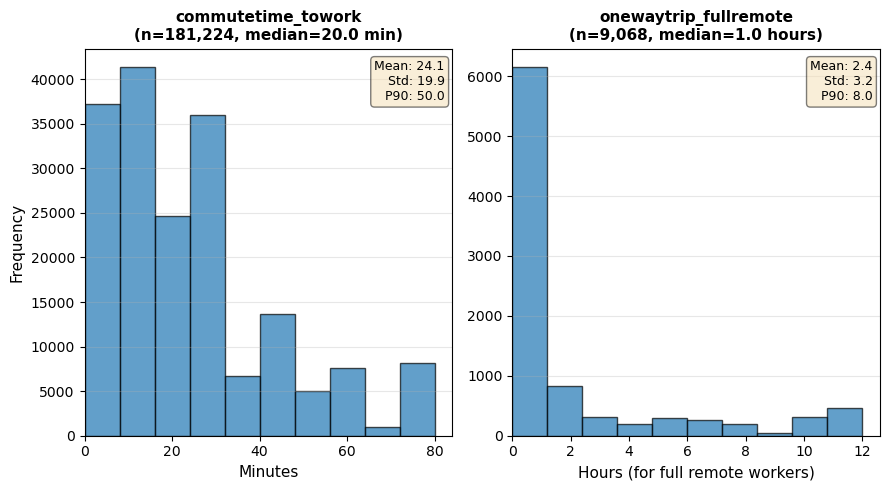

In [12]:
# Check the main commute time variable distributions to get clarity on unit- note we pool across years here
# the first two are in minutes, while the last one for remote workers are in hours, evidently. Not
# spelled out in the data dict

commute_vars = [#'commutetime_quant', 
                'commutetime_towork', 'onewaytrip_fullremote']

# Plot distributions of the three commute variables
fig, axes = plt.subplots(1, len(commute_vars), figsize=(9, 5))

for idx, var in enumerate(commute_vars):

    comm_data = pd.to_numeric(df[var], errors='coerce')
    valid_data = comm_data.dropna()
    
    axes[idx].hist(valid_data, bins=10, edgecolor='black', alpha=0.7)
    axes[idx].set_xlim(left=0)
    
    if not var=='onewaytrip_fullremote':
        axes[idx].set_xlabel('Minutes', fontsize=11)
        ttl = f'{var}\n(n={len(valid_data):,}, median={valid_data.median():.1f} min)'
    else:
        axes[idx].set_xlabel('Hours (for full remote workers)', fontsize=11)
        ttl = f'{var}\n(n={len(valid_data):,}, median={valid_data.median():.1f} hours)'
    if idx == 0:
        axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(ttl, 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add stats as text
    axes[idx].text(0.98, 0.97, 
                    f'Mean: {valid_data.mean():.1f}\n'
                    f'Std: {valid_data.std():.1f}\n'
                    f'P90: {valid_data.quantile(0.90):.1f}',
                    transform=axes[idx].transAxes,
                    verticalalignment='top',
                    horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                    fontsize=9)


plt.tight_layout()
plt.show()


In [13]:

# Set to a column name (e.g. 'commutetime_towork') to enable commute tabulations, or None to skip
COMMUTE_COL = 'commutetime_towork'

# # Use the primary commute variable for analysis
# COMMUTE_COL = 'commutetime_towork'

# comm = pd.to_numeric(df[COMMUTE_COL], errors='coerce')
# if comm.notna().any():
#     df['commute_bin'] = pd.cut(
#         comm,
#         bins=[-np.inf, 15, 30, 45, 60, 90, np.inf],
#         labels=['<=15', '16-30', '31-45', '46-60', '61-90', '90+'],
#     ).astype('string').fillna('Missing or NA')

#     print(f"\nUsing commute variable: {COMMUTE_COL}")# df['commute_bin'].value_counts(dropna=False)
#     print(f"  Valid values: {comm.notna().sum():,} / {len(df):,} ({comm.notna().sum()/len(df)*100:.1f}%)")

### Employment Status and Worker Universe Flags

In [14]:

# Wage/Salary worker flag (Bloom et al. universe for WFH trends)
# self_employment: 1-2 = Wage/Salary, 3-4 = Self-employed/Contractor

self_emp = pd.to_numeric(df['self_employment'], errors='coerce')
df['is_wage_salary'] = (self_emp <= 2).astype('boolean')

# Broader worker universe flag: any employment type currently working for pay
workstat_new = pd.to_numeric(df['workstatus_current_new'], errors='coerce')
df['is_any_worker'] = (
    self_emp.notna() &  # Has employment type (1-4) 
    (workstat_new == 1)  # Currently working for pay
).astype('boolean')

pd.DataFrame({
    'wage_salary':            [df['is_wage_salary'].sum()],
    'any_worker':             [df['is_any_worker'].sum()],
    'self_employed_contract': [(df['is_any_worker'] & ~df['is_wage_salary']).sum()],
})


,wage_salary,any_worker,self_employed_contract
0,239484,254830,29331


### Remote Arrangement - According to Employer Plans


In [15]:

# Based on *employer's* WFH plans/policies (wfh_days_postCOVID_boss) - different than actual WFH

boss_days = pd.to_numeric(df['wfh_days_postCOVID_boss'], errors='coerce')

# variable is continuous, counting days
arrangement_map = {
    1: 'Mostly On-Premises',
    2: 'Mostly On-Premises',
    3: 'Hybrid (1-4 days WFH)',
    4: 'Hybrid (1-4 days WFH)',
    5: 'Hybrid (1-4 days WFH)',
    6: 'Hybrid (1-4 days WFH)',
    7: 'Fully Remote (5+ days WFH)',
    8: 'No Clear Employer Plans',
    9: 'No Employer'
}
df['remote_arrangement_employer'] = boss_days.map(arrangement_map).astype('string')

# Binary flags (cast to object so == comparisons return numpy bool arrays for np.select)
_arr = df['remote_arrangement_employer'].astype(object)

df['is_fully_remote'] = np.select(
    [_arr == 'Fully Remote (5+ days WFH)', _arr.notna()], [1.0, 0.0], default=np.nan)
df['is_hybrid'] = np.select(
    [_arr == 'Hybrid (1-4 days WFH)', _arr.notna()], [1.0, 0.0], default=np.nan)
df['is_fully_remote_incl_missing'] = df['is_fully_remote'].fillna(0.0)

df['remote_arrangement_employer'].value_counts(dropna=False)


remote_arrangement_employer
Mostly On-Premises            113702
Hybrid (1-4 days WFH)          95931
No Employer                    65296
Fully Remote (5+ days WFH)     44196
No Clear Employer Plans        34976
Name: count, dtype: Int64

### Remote Arrangement - Actual, according to Matrix Variables
Data dict reports `work_wfhdays_mat` as:
> Total number of days working from home last week - from matrix question w/o restricting by work status


In [16]:

# Use work_wfhdays_mat (WFH days count) to classify arrangement
# Note: Matrix variable may include weekend work days if reported
# But we use same classification logic: 5+ WFH days = Fully Remote for consistency

# Convert first to numeric
wfh_days_mat = pd.to_numeric(df['work_wfhdays_mat'], errors='coerce')
premises_days_mat = pd.to_numeric(df['work_wbpdays_mat'], errors='coerce')
all_days_mat = pd.to_numeric(df['work_alldays_mat'], errors='coerce')

# Classification: 0 = Mostly On-Premises, 1-4 = Hybrid, 5+ = Fully Remote
wfh_days_arrangement_map = {
    0: 'Mostly On-Premises',
    1: 'Hybrid (1-4 days WFH)',
    2: 'Hybrid (1-4 days WFH)',
    3: 'Hybrid (1-4 days WFH)',
    4: 'Hybrid (1-4 days WFH)',
    5: 'Fully Remote (5+ days WFH)',
    6: 'Fully Remote (5+ days WFH)',
    7: 'Fully Remote (5+ days WFH)',
}

df['remote_arrangement_mat'] = wfh_days_mat.map(wfh_days_arrangement_map)
# Handle 8+ days (edge cases) - treat as Fully Remote
df.loc[wfh_days_mat >= 8, 'remote_arrangement_mat'] = 'Fully Remote (5+ days WFH)'
df['remote_arrangement_mat'] = df['remote_arrangement_mat'].astype('string')

display(pd.DataFrame({
    'work_wfhdays_mat':  wfh_days_mat.value_counts(dropna=False).sort_index(),
    'work_alldays_mat':  all_days_mat.value_counts(dropna=False).sort_index(),
    'work_wbpdays_mat':  premises_days_mat.value_counts(dropna=False).sort_index(),
}))
df['remote_arrangement_mat'].value_counts(dropna=False)


,work_wfhdays_mat,work_alldays_mat,work_wbpdays_mat
0.0,198355,72400,126728
1.0,23956,3661,12925
2.0,35986,7229,24203
3.0,25784,15451,32509
4.0,15931,30725,33938
5.0,25006,122446,80123
6.0,4419,34819,17122
7.0,15390,58096,17279
NaN,9274,9274,9274


remote_arrangement_mat
Mostly On-Premises            198355
Hybrid (1-4 days WFH)         101657
Fully Remote (5+ days WFH)     44815
<NA>                            9274
Name: count, dtype: Int64

### Remote Arrangement - Actual, reported via individual weekday variables
Data dict reports `workstatus_monday` ... `workstatus_sunday` as categorical as follows:
```
workstatus_days 1 "Did not work"
workstatus_days 2 "Worked from home"
workstatus_days 3 "Worked on employer or client premises"
```

In [17]:

# Note: Focusing on weekdays for clarity and consistency with standard work week patterns

weekday_vars = ['workstatus_monday', 'workstatus_tuesday', 'workstatus_wednesday', 
                'workstatus_thursday', 'workstatus_friday']

# coding for day_status: 1=On premises, 2=WFH, 3=Not working, NA=Missing

# Check which weekday variables are available
available_days = [v for v in weekday_vars if v in df.columns]

if len(available_days) >= 3:
    # Ensure all day variables are numeric
    for col in available_days:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Count days by work status using vectorized operations
    status_codes = {1: 'days_premises', 2: 'days_wfh', 3: 'not_working_count'}
    for code, name in status_codes.items():
        df[name] = (df[available_days] == code).sum(axis=1)
    
    df['days_reported'] = df[['days_premises', 'days_wfh', 'not_working_count']].sum(axis=1)
    
    # Classify arrangement based on weekday WFH count (requires 3+ weekdays reported)
    # Classification: 0 WFH days = On-Premises, 1-4 = Hybrid, 5 = Fully Remote
    has_data_mask = df['days_reported'] >= 3
    df['remote_arrangement_actual'] = np.select(
        [has_data_mask & (df['days_wfh'] >= 5),
         has_data_mask & df['days_wfh'].between(1, 4),
         has_data_mask & (df['days_wfh'] == 0) & (df['days_premises'] >= 1)],
        ['Fully Remote (5+ days WFH)', 'Hybrid (1-4 days WFH)', 'Mostly On-Premises'],
        default=pd.NA,
    )
    
    display(df['remote_arrangement_actual'].value_counts(dropna=False).sort_index())
else:
    print(f"Insufficient weekday variables (need >= 3): {available_days}")


remote_arrangement_actual
Fully Remote (5+ days WFH)     39467
Hybrid (1-4 days WFH)          91555
Mostly On-Premises            119338
<NA>                          103741
Name: count, dtype: int64

### Combined Work Arrangement Variable

For convenience, we can create a hybrid variable that uses actual behavior where available, with employer plans for Oct/Nov 2023 gaps. However, for Tableau analysis, it's cleaner to use `remote_arrangement_employer` and `remote_arrangement_actual` separately.

### Work Arrangement Variables

Primary Variables (use these for Tableau analysis):

- `remote_arrangement_employer`
  - Employer's WFH plans/policies from `wfh_days_postCOVID_boss`
  - Categories: Mostly On-Premises, Hybrid (1-4 days WFH), Fully Remote (5+ days WFH)
  - Also: 'No Clear Employer Plans', 'No Employer'
  - Use for: Understanding employer policies, filtering to workers with employers
  
- `remote_arrangement_actual`
  - Actual work location behavior from day-of-week variables
  - Requires 3+ days reported for classification
  - Same categories as employer variable (Mostly On-Premises, Hybrid, Fully Remote)
  - Use for understanding actual behavior regardless of employer status

Supporting Variables:

- **`days_wfh`, `days_premises`, `days_reported`**: Day counts for actual behavior
- **`self_employment`**: Employment type (1-2: Wage/Salary, 3-4: Self-employed/Contractor)
- **`is_wage_salary`**: Wage/salary workers (self_employment ≤ 2) - Bloom et al. universe
- **`is_any_worker`**: All employment types currently working for pay

Optional Combined Variable:

- **`work_arrangement`**: Combines actual + employer backfill for Oct/Nov 2023 gaps
  - Source tracked in `work_arrangement_source`: 'actual', 'employer_backfill', or NA
  - Can use for Python analysis, but two separate variables cleaner for Tableau

In [18]:

# Authors' universe for Figure 2 replication (from "The Evolution of Work From Home" JEP paper)
# Stata filters: work_alldays_mat>=5 & workstatus_current_new==1 & self_employment<=2
_universe_conditions = {
    'work_alldays_mat':       lambda s: pd.to_numeric(s, errors='coerce') >= 5,
    'workstatus_current_new': lambda s: pd.to_numeric(s, errors='coerce') == 1,
    'self_employment':        lambda s: pd.to_numeric(s, errors='coerce') <= 2,
}
df['authors_universe'] = np.logical_and.reduce(
    [fn(df[col]) for col, fn in _universe_conditions.items() if col in df.columns]
)

n_universe = df['authors_universe'].sum()
n_total = len(df)
n_with_arrangement = (df['authors_universe'] & df['remote_arrangement_employer'].notna()).sum()

pd.DataFrame({
    'n': [n_universe, n_with_arrangement, n_total],
    'pct_of_total': [n_universe/n_total*100, n_with_arrangement/n_total*100, 100.0],
}, index=['authors_universe', 'universe + known arrangement', 'total']).style.format({'n': '{:,.0f}', 'pct_of_total': '{:.1f}%'})


,n,pct_of_total
authors_universe,"175,571",49.6%
universe + known arrangement,"175,571",49.6%
total,"354,101",100.0%



### Quick Gate Check: Figure 2 Replication - Mean WFH Days by Industry

Replicates **Figure 2** from Barrero, Bloom, and Davis, *"The Evolution of Work From Home"*, Journal of Economic Perspectives (2023): mean WFH days per week by industry for full-time wage/salary workers, Jan - Jun 2023.

**Key details from `Figure2.do`:**
- Dataset: `WFHdata_noincreq` (no income requirement) - we use the income-req version (`WFHdata_April26.csv`), which may explain small residual differences
- Date range: **Jan 2023  -  Jun 2023**
- Universe: `work_alldays_mat >= 5`, `workstatus_current_new == 1`, `self_employment <= 2`
- Attention checks: `grass_color_attnfull` ∈ {2, 3, missing}, `cities_attn` ∈ {33, missing}, `sum3plus4` ∈ {7, missing}
- **Excluded industries**: Agriculture (1) and Mining (10)
- Weights: `cratio100` directly (`df['w']`), not population-scaled weights

*Note: The JEP paper's Figure 3 is a WFH-vs-population-density binscatter - unrelated to this chart. The figure numbering differs between the draft working paper and the published JEP version.*

![image.png](figure2.png){width=50%}



In [19]:

# %time
# fig2_data.groupby('industry_label').apply(weighted_mean,value_col='work_wfhdays_mat')
# vs 

In [20]:

# %time
# weighted_mean(fig2_data, value_col='work_wfhdays_mat', group_cols=['industry_label'])


In [21]:

# Figure 2 gate check: Jan - Jun 2023 baseline (matches Figure2.do exactly)
# Weights: cratio100 (df['w']) -  not population-scaled

# Attention check filters (|. means pass if question wasn't asked)
attn_grass  = df['grass_color_attnfull'].isin([2, 3]) | df['grass_color_attnfull'].isna()
attn_cities = pd.to_numeric(df['cities_attn'], errors='coerce').eq(33) | df['cities_attn'].isna()
attn_sum    = pd.to_numeric(df['sum3plus4'],   errors='coerce').eq(7)  | df['sum3plus4'].isna()
attn_pass   = attn_grass & attn_cities & attn_sum

# Excluded industries: Agriculture (1), Mining (10)
excl_ind = pd.to_numeric(df['work_industry'], errors='coerce').isin([1, 10])

fig2_period = (df['date_ts'] >= '2023-01-01') & (df['date_ts'] <= '2023-06-30')
fig2_mask   = fig2_period & df['authors_universe'] & attn_pass & ~excl_ind
fig2_data   = df[fig2_mask].copy()

fig2_df = (
    weighted_mean(fig2_data, value_col='work_wfhdays_mat', group_cols=['industry_label'], weight_col='w')
    .rename(columns={'industry_label': 'industry', 'weighted_mean': 'mean_wfh_days_2023',
                     'unweighted_n': 'sample_size_2023'})
    .sort_values('mean_wfh_days_2023', ascending=False)
    .reset_index(drop=True)
)

overall_mean_2023 = weighted_mean(fig2_data, value_col='work_wfhdays_mat', weight_col='w')['weighted_mean'].iloc[0]

display(fig2_df[['industry', 'mean_wfh_days_2023', 'sample_size_2023']]
        .style.format({'mean_wfh_days_2023': '{:.2f}', 'sample_size_2023': '{:,.0f}'})
        .set_caption(f'Figure 2 Gate Check - Mean WFH Days by Industry (Jan - Jun 2023); overall mean = {overall_mean_2023:.2f}'))


,industry,mean_wfh_days_2023,sample_size_2023
0,Information,2.51,"1,777"
1,Missing/Other,2.29,97
2,Finance & Insurance,2.27,"2,765"
3,Professional & Business Services,2.04,"2,658"
4,Arts & Entertainment,1.86,286
5,Wholesale Trade,1.59,247
6,Health Care & Social Assistance,1.56,"2,861"
7,Utilities,1.53,268
8,Construction,1.29,"2,549"
9,Government,1.27,854


In [22]:

# Sanity-check: overall mean for the baseline period vs paper
overall_mat = weighted_mean(fig2_data, value_col='work_wfhdays_mat', weight_col='w')['weighted_mean'].iloc[0]
overall_n_mat = fig2_data['work_wfhdays_mat'].notna().sum()

# Paper overall mean is approximately 1.40 days/week from the chart
pd.DataFrame({'replicated': [overall_mat], 'paper_fig2': [1.40], 'n': [overall_n_mat]}).style.format({'replicated': '{:.3f}', 'paper_fig2': '{:.2f}', 'n': '{:,.0f}'})


,replicated,paper_fig2,n
0,1.345,1.40,"22,629"


In [23]:

# Recent period (2025 Jul - 2026 Apr) for comparison, same filters as baseline

fig2_recent = (df['date_ts'] >= '2025-07-01') & (df['date_ts'] <= '2026-04-30')
fig2_recent_mask = fig2_recent & df['authors_universe'] & attn_pass & ~excl_ind
fig2_recent_data = df[fig2_recent_mask].copy()

fig2_recent_df = (
    weighted_mean(fig2_recent_data, value_col='work_wfhdays_mat', group_cols=['industry_label'], weight_col='w')
    .rename(columns={'industry_label': 'industry', 'weighted_mean': 'mean_wfh_days_recent',
                     'unweighted_n': 'sample_size_recent'})
)

overall_mean_recent = weighted_mean(fig2_recent_data, value_col='work_wfhdays_mat', weight_col='w')['weighted_mean'].iloc[0]

# Merge for comparison
fig2_comparison = (
    fig2_df.merge(fig2_recent_df[['industry', 'mean_wfh_days_recent', 'sample_size_recent']], on='industry')
)
fig2_comparison['change'] = fig2_comparison['mean_wfh_days_recent'] - fig2_comparison['mean_wfh_days_2023']
fig2_comparison = fig2_comparison.sort_values('mean_wfh_days_2023', ascending=False)

overall_change = overall_mean_recent - overall_mean_2023

display(fig2_comparison[['industry', 'mean_wfh_days_2023', 'mean_wfh_days_recent', 'change']]
        .style.format({'mean_wfh_days_2023': '{:.2f}', 'mean_wfh_days_recent': '{:.2f}', 'change': '{:+.2f}'})
        .set_caption(f'2023 vs 2025 - 26: overall {overall_mean_2023:.2f} → {overall_mean_recent:.2f} ({overall_change:+.2f})'))


,industry,mean_wfh_days_2023,mean_wfh_days_recent,change
0,Information,2.51,2.18,-0.34
1,Missing/Other,2.29,2.45,+0.17
2,Finance & Insurance,2.27,2.30,+0.03
3,Professional & Business Services,2.04,1.87,-0.17
4,Arts & Entertainment,1.86,1.70,-0.17
5,Wholesale Trade,1.59,1.75,+0.15
6,Health Care & Social Assistance,1.56,1.55,-0.00
7,Utilities,1.53,1.42,-0.12
8,Construction,1.29,0.99,-0.30
9,Government,1.27,1.02,-0.26


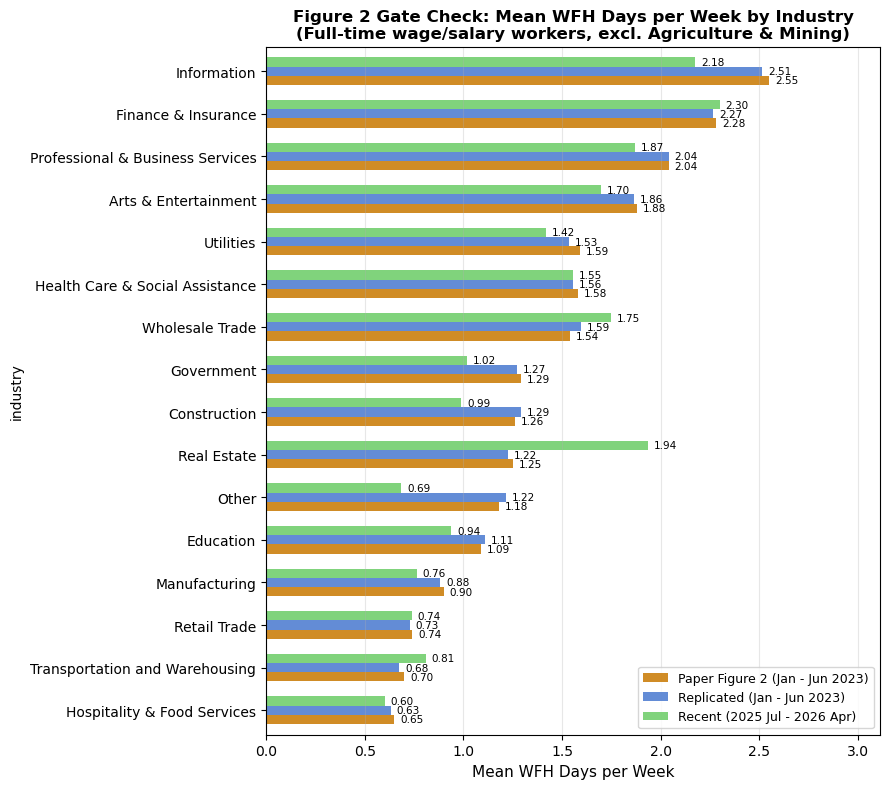

In [24]:

# Paper Figure 2 values (Barrero, Bloom & Davis JEP 2023, Jan-Jun 2023 baseline)
# "Other Personal Services" in paper = 'Other' in industry_map
# "Information (incl. part of tech)" in paper = 'Information' in industry_map
# Agriculture and Mining excluded per Figure2.do

fig2_paper = {
    'Information':                        2.55,
    'Finance & Insurance':                2.28,
    'Professional & Business Services':   2.04,
    'Arts & Entertainment':               1.88,
    'Utilities':                          1.59,
    'Health Care & Social Assistance':    1.58,
    'Wholesale Trade':                    1.54,
    'Government':                         1.29,
    'Construction':                       1.26,
    'Real Estate':                        1.25,
    'Other':                              1.18,
    'Education':                          1.09,
    'Manufacturing':                      0.90,
    'Retail Trade':                       0.74,
    'Transportation and Warehousing':     0.70,
    'Hospitality & Food Services':        0.65,
}

# Build comparison frame: paper + replication + recent, sorted by paper
fig2_chart = fig2_comparison.copy()
fig2_chart['paper'] = fig2_chart['industry'].map(fig2_paper)
fig2_chart = fig2_chart.dropna(subset=['paper']).sort_values('paper', ascending=True).reset_index(drop=True)

col_labels = {
    'paper':                'Paper Figure 2 (Jan - Jun 2023)',
    'mean_wfh_days_2023':   'Replicated (Jan - Jun 2023)',
    'mean_wfh_days_recent': 'Recent (2025 Jul - 2026 Apr)',
}

ax = (fig2_chart.set_index('industry')[list(col_labels)]
          .rename(columns=col_labels)
          .plot.barh(figsize=(9, max(6, len(fig2_chart) * 0.5)),
                     color=['#C87800', '#4878CF', '#6ACC65'],
                     alpha=0.85, width=0.65))

for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 0.03, bar.get_y() + bar.get_height() / 2, f'{w:.2f}',
            va='center', ha='left', fontsize=7.5)

ax.set_xlabel('Mean WFH Days per Week', fontsize=11)
ax.set_title('Figure 2 Gate Check: Mean WFH Days per Week by Industry\n'
             '(Full-time wage/salary workers, excl. Agriculture & Mining)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, fig2_chart[list(col_labels)].max().max() * 1.22)
plt.tight_layout()
plt.show()


This is pretty close. As to what changed since, we note real estate shot up, while information dropped, leaving finance / insurance in the lead.


<a id="tabulations"></a>
## Tabulations


<a id="arrangement-prevalence"></a>
### Remote Work Arrangement Prevalence


In [25]:

arrangement_summary = weighted_distribution(
    df,
    category_col='remote_arrangement_employer',
    group_cols=['period']
)

pivot_by_period(
    arrangement_summary,
    label_col='remote_arrangement_employer',
    value_cols={
        'unweighted_n':  ('N',          '{:,.0f}', 1),
        'pct_of_total':  ('Weighted %', '{:.1f}%', 1),
    }
)


C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')


<a id="commute-arrangement"></a>
### Commute Patterns by Work Arrangement


In [26]:

commute_by_arrangement = None

if COMMUTE_COL and 'remote_arrangement_employer' in df.columns:
     valid_comm_mask = df['remote_arrangement_employer'].notna() & df[COMMUTE_COL].notna()
     if valid_comm_mask.any():
         commute_by_arrangement = weighted_mean(
             df, value_col=COMMUTE_COL, group_cols=['period', 'remote_arrangement_employer'],
             filter_mask=valid_comm_mask
         ).sort_values(['period', 'weighted_mean'])

         pivot_by_period(
             commute_by_arrangement,
             label_col='remote_arrangement_employer',
             value_cols={
                 'weighted_mean': ('Mean (min)', '{:.1f}', 1),
                 'unweighted_n':  ('N',          '{:,.0f}', 1),
             }
         )
     else:
         commute_by_arrangement = None
else:

     commute_by_arrangement = None

C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

In [27]:
# Output remote_arrangement data for tableau
# Use weighted_distribution to get normalized percentages that sum to 100% within each period
remote_arrangement_for_tableau = weighted_distribution(
    df,
    category_col='remote_arrangement_actual',
    group_cols=['date_ts','remote_arrangement_employer']
)

remote_arrangement_for_tableau.groupby(['date_ts','remote_arrangement_employer','remote_arrangement_actual'],as_index=False).sum()


,date_ts,remote_arrangement_employer,remote_arrangement_actual,unweighted_n,weighted_n,pct_of_total
0,2022-01-01,Fully Remote (5+ days WFH),Fully Remote (5+ days WFH),326,5.632251e+06,44.261615
1,2022-01-01,Fully Remote (5+ days WFH),Hybrid (1-4 days WFH),239,3.443010e+06,27.057241
2,2022-01-01,Fully Remote (5+ days WFH),Mostly On-Premises,69,1.549777e+06,12.179078
3,2022-01-01,Hybrid (1-4 days WFH),Fully Remote (5+ days WFH),194,3.894837e+06,14.358928
4,2022-01-01,Hybrid (1-4 days WFH),Hybrid (1-4 days WFH),1100,1.568733e+07,57.833800
...,...,...,...,...,...,...
730,2026-04-01,No Clear Employer Plans,Hybrid (1-4 days WFH),176,3.473035e+06,20.064482
731,2026-04-01,No Clear Employer Plans,Mostly On-Premises,203,6.463381e+06,37.340368
732,2026-04-01,No Employer,Fully Remote (5+ days WFH),160,4.461817e+06,8.445158
733,2026-04-01,No Employer,Hybrid (1-4 days WFH),89,2.622699e+06,4.964145


In [28]:
remote_arrangement_for_tableau_direct = df.groupby(['date_ts','csa_mismatch_flag','remote_arrangement_mat','remote_arrangement_employer','remote_arrangement_actual'],as_index=False,dropna=False).w_population.sum()
remote_arrangement_for_tableau_direct.sample(10)

,date_ts,csa_mismatch_flag,remote_arrangement_mat,remote_arrangement_employer,remote_arrangement_actual,w_population
1467,2024-01-01,Same CSA,Fully Remote (5+ days WFH),Fully Remote (5+ days WFH),Fully Remote (5+ days WFH),5.401372e+06
1903,2024-08-01,Different CSA,Fully Remote (5+ days WFH),Fully Remote (5+ days WFH),Fully Remote (5+ days WFH),1.829856e+06
2015,2024-09-01,Same CSA,Hybrid (1-4 days WFH),Hybrid (1-4 days WFH),Hybrid (1-4 days WFH),1.272611e+07
370,2022-09-01,Same CSA,Fully Remote (5+ days WFH),Hybrid (1-4 days WFH),Hybrid (1-4 days WFH),4.742557e+05
2553,2025-05-01,Same CSA,Hybrid (1-4 days WFH),Mostly On-Premises,Mostly On-Premises,1.548078e+05
2742,2025-08-01,Same CSA,Fully Remote (5+ days WFH),Hybrid (1-4 days WFH),Fully Remote (5+ days WFH),1.742926e+06
2989,2025-12-01,Different CSA,Fully Remote (5+ days WFH),No Employer,Fully Remote (5+ days WFH),1.733065e+06
1031,2023-07-01,Different CSA,Hybrid (1-4 days WFH),No Clear Employer Plans,Mostly On-Premises,9.252837e+04
1294,2023-11-01,Different CSA,Fully Remote (5+ days WFH),No Clear Employer Plans,Fully Remote (5+ days WFH),1.221344e+05
173,2022-06-01,Same CSA,Fully Remote (5+ days WFH),No Clear Employer Plans,Hybrid (1-4 days WFH),5.398133e+04


<a id="csa-location-decoupled"></a>
### Location-Decoupled WFH (Cross-CSA)

Among fully remote workers with valid geocoded home and job CSA, what share lives in a different metro than their employer? This captures workers who have fully "decoupled" residence from job location - relevant for understanding population redistribution effects of remote work. Worth tracking over time.


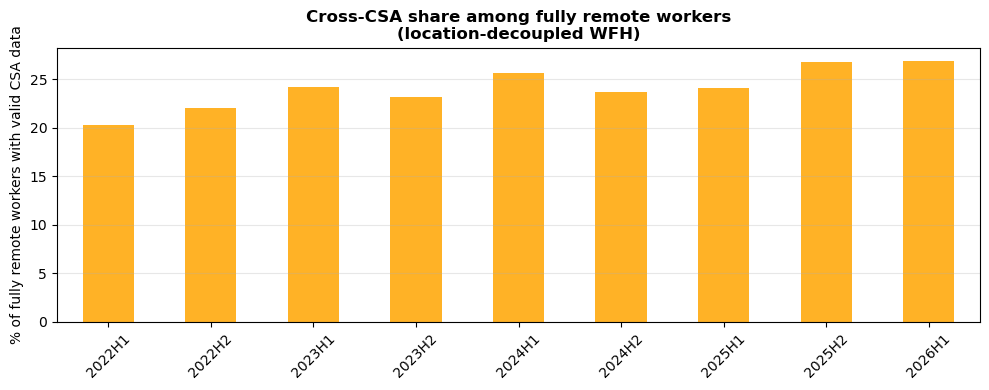

,diff_csa_pct_of_fully_remote
period,
2022H1,20.3%
2022H2,22.1%
2023H1,24.2%
2023H2,23.2%
2024H1,25.6%
2024H2,23.6%
2025H1,24.1%
2025H2,26.8%
2026H1,26.9%


In [39]:

# Among fully remote workers, what share has their employer in a different CSA from where they live?
# These are location-decoupled workers - genuinely untethered from the job's metro area.
# Denominator: fully remote workers with valid CSA data on both home and job side.

remote_csa_flip = weighted_distribution(
    df[df['csa_mismatch_flag'].notna() & (df['remote_arrangement_actual'] == 'Fully Remote (5+ days WFH)')],
    category_col='csa_mismatch_flag',
    group_cols=['period']
)
ts_diff_csa_among_remote = (
    remote_csa_flip
    .query('csa_mismatch_flag == "Different CSA"')
    .set_index('period')['pct_of_total']
)

ax = ts_diff_csa_among_remote.plot(kind='bar', figsize=(10, 4), color='orange', alpha=0.85)
ax.set_title('Cross-CSA share among fully remote workers\n(location-decoupled WFH)', fontsize=12, fontweight='bold')
ax.set_ylabel('% of fully remote workers with valid CSA data')
ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(ts_diff_csa_among_remote.rename('diff_csa_pct_of_fully_remote').to_frame().style.format('{:.1f}%'))


<a id="industry-occupation"></a>
### Industry & Occupation Analysis

Shows main remote work share by industry - over time

In [30]:

if 'industry_label' in df.columns and 'is_fully_remote_incl_missing' in df.columns:
    industry_remote = weighted_mean(
        df, value_col='is_fully_remote_incl_missing', group_cols=['period', 'industry_label'],
        filter_mask=df['industry_label'].notna()
    )
    top_industries = industry_remote.groupby('industry_label')['unweighted_n'].sum().nlargest(10).index
    industry_remote_top10 = industry_remote[industry_remote['industry_label'].isin(top_industries)]

    pivot_by_period(
        industry_remote_top10,
        label_col='industry_label',
        value_cols={
            'weighted_mean': ('Remote %', '{:.1%}', 1),
            'unweighted_n':  ('N',         '{:,.0f}', 1),
        },
        sort_by='weighted_mean',
        ascending=False
    )
else:
    industry_remote_top10 = None


C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

In [31]:

if 'occupation_label' in df.columns and 'is_fully_remote_incl_missing' in df.columns:
    occupation_remote = weighted_mean(
        df, value_col='is_fully_remote_incl_missing', group_cols=['period', 'occupation_label'],
        filter_mask=df['occupation_label'].notna()
    )
    top_occupations = occupation_remote.groupby('occupation_label')['unweighted_n'].sum().nlargest(10).index
    occupation_remote_top10 = occupation_remote[occupation_remote['occupation_label'].isin(top_occupations)]

    pivot_by_period(
        occupation_remote_top10,
        label_col='occupation_label',
        value_cols={
            'weighted_mean': ('Remote %', '{:.1%}', 1),
            'unweighted_n':  ('N',         '{:,.0f}', 1),
        },
        sort_by='weighted_mean',
        ascending=False
    )
else:
    occupation_remote_top10 = None


C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

In [32]:
commute_by_csa = weighted_mean(
        df, value_col='work_wfhdays_mat', group_cols=['period', 'csa_mismatch_flag'],
        filter_mask=df['work_wfhdays_mat'].notna()
    ).sort_values(['period', 'csa_mismatch_flag'])
commute_by_csa

C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({


,period,csa_mismatch_flag,weighted_num,weighted_den,unweighted_n,weighted_mean
0,2022H1,Different CSA,1.155878e+08,1.223548e+08,3832,0.944693
1,2022H1,Same CSA,4.687608e+08,3.692962e+08,15857,1.269336
2,2022H2,Different CSA,2.308557e+08,2.546263e+08,8964,0.906645
3,2022H2,Same CSA,8.973870e+08,7.326687e+08,38578,1.224820
4,2023H1,Different CSA,2.502142e+08,2.442846e+08,8426,1.024273
5,2023H1,Same CSA,9.281822e+08,7.553364e+08,39782,1.228833
6,2023H2,Different CSA,2.335476e+08,2.015234e+08,6827,1.158910
7,2023H2,Same CSA,9.127322e+08,6.456783e+08,30252,1.413602
8,2024H1,Different CSA,2.521718e+08,2.651144e+08,8747,0.951181
9,2024H1,Same CSA,8.833599e+08,7.415096e+08,32495,1.191299


<a id="commute-demographics"></a>
### Commute Patterns by Demographics


In [33]:

commute_by_age = None
if COMMUTE_COL and 'agebin_label' in df.columns:
    commute_by_age = weighted_mean(
        df, value_col=COMMUTE_COL, group_cols=['period', 'agebin_label'],
        filter_mask=df[COMMUTE_COL].notna()
    ).sort_values(['period', 'agebin_label'])

    pivot_by_period(
        commute_by_age,
        label_col='agebin_label',
        value_cols={
            'weighted_mean': ('Mean (min)', '{:.1f}', 1),
            'unweighted_n':  ('N',          '{:,.0f}', 1),
        }
    )
else:
    commute_by_age = None


C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

In [34]:

commute_by_tenure = None
if COMMUTE_COL and 'resi_tenure_label' in df.columns:
    commute_by_tenure = weighted_mean(
        df, value_col=COMMUTE_COL, group_cols=['period', 'resi_tenure_label'],
        filter_mask=df[COMMUTE_COL].notna()
    ).sort_values(['period', 'resi_tenure_label'])

    pivot_by_period(
        commute_by_tenure,
        label_col='resi_tenure_label',
        value_cols={
            'weighted_mean': ('Mean (min)', '{:.1f}', 1),
            'unweighted_n':  ('N',          '{:,.0f}', 1),
        }
    )
else:
    commute_by_tenure = None


C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = tmp.groupby(group_cols, dropna=False).agg({
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p = data.pivot_table(index=label_col, columns='period', values=src, aggfunc='first')
C:\Users\aolsen\AppData\Local\Temp\ipykernel_31356\3645503903.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

<a id="export"></a>
## Export


<a id="export-excel"></a>
### Export to Excel


In [35]:
# Export all summary tables to Excel
output_dir = os.path.dirname(DATA_PATH)
excel_path = os.path.join(output_dir, 'SWAA_remote_work_analysis_us.xlsx')

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Arrangement prevalence
    if arrangement_summary is not None:
        arrangement_summary.to_excel(writer, sheet_name='Arrangement_Prevalence', index=False)

    # Sheet 2: Location-decoupled WFH (cross-CSA share among fully remote workers)
    if 'ts_diff_csa_among_remote' in dir() and ts_diff_csa_among_remote is not None:
        ts_diff_csa_among_remote.rename('diff_csa_pct_of_fully_remote').reset_index().to_excel(
            writer, sheet_name='CrossCSA_Remote', index=False)

    # Sheet 3: Commute by arrangement
    # if commute_by_arrangement is not None:
    #     commute_by_arrangement.to_excel(writer, sheet_name='Commute_by_Arrangement', index=False)

    # Sheet 4: Industry fully remote
    if industry_remote_top10 is not None:
        industry_remote.to_excel(writer, sheet_name='Industry_Remote_Rates', index=False)

    # Sheet 5: Occupation fully remote
    if occupation_remote_top10 is not None:
        occupation_remote.to_excel(writer, sheet_name='Occupation_Remote_Rates', index=False)

    # Sheet 6: Figure 2 comparison (from "The Evolution of Work From Home" JEP paper)
    if fig2_comparison is not None:
        fig2_comparison.to_excel(writer, sheet_name='Figure2_WFH_Days', index=False)

    # Sheet 7: Commute by age
    if commute_by_age is not None:
        commute_by_age.to_excel(writer, sheet_name='Commute_by_Age', index=False)

    # Sheet 8: Commute by tenure
    if commute_by_tenure is not None:
        commute_by_tenure.to_excel(writer, sheet_name='Commute_by_Tenure', index=False)

print(f"\n✓ Analysis complete. Results exported to:\n  {excel_path}")



✓ Analysis complete. Results exported to:
  M:\Data\SWAA\WFH_Code_and_Data_May2020_to_April2026\SWAA_remote_work_analysis_us.xlsx


<a id="export-tableau"></a>
### Export to Tableau


In [36]:
tableau_path = pathlib.Path(M_DRIVE) / 'Projects/Worker Flows'

remote_arrangement_for_tableau.to_csv(tableau_path / 'remote_arrangement_for_tableau.csv', index=False)

remote_arrangement_for_tableau_direct.to_csv(tableau_path / 'remote_arrangement_for_tableau_direct.csv', index=False)


In [37]:
# also write out a combination dataframe for deeper investigation of input variables and their intersections
test_groups = ['workstatus_current_lbl','workstatus_current_new_lbl','self_employment_lbl','remote_arrangement_employer', 'remote_arrangement_mat', 'remote_arrangement_actual']
df_combinations = df.groupby(['date_ts']+test_groups,dropna=False,as_index=False).w_population.sum()
df_combinations.to_csv(tableau_path / 'combination_counts.csv', index=False)    


In [38]:
df[['date_ts']+test_groups+['industry_label','occupation_label','w_population']].to_csv(tableau_path / 'df_disaggregate_combination_counts.csv', index=False)    